## Gradient Descent:
- **Gradient Descent** is an optimization algorithm used to minimize loss (error) by updating model parameters step by step.

- **Simple:**
  It finds the best weights that reduce prediction error


**Types of Gradient Descent**:
- 1. `Batch Gradient Descent`
  2. `Stochistic Gradient Descent`
  3. `Mini Batch Gradient Descent`

### Gradient Descent Manually code:

In [13]:
import numpy as np

def batch_gradient_descent(X, y, alpha=0.01, epochs=100, verbose=True):
    """
    Batch Gradient Descent for Linear Regression
    
    Args:
        X: Input features (m × n)
        y: Target values (m,)
        alpha: Learning rate
        epochs: Number of iterations
        verbose: Print progress
    
    Returns:
        w: Learned weights
        b: Learned bias
        losses: Loss history
    """
    m = len(y)
    n = X.shape[1]
    
    # Initialize parameters
    w = np.zeros(n)
    b = 0
    losses = []
    
    for epoch in range(epochs):
        # Forward pass
        y_pred = X @ w + b
        
        # Compute loss
        loss = (1/(2*m)) * np.sum((y_pred - y)**2)
        losses.append(loss)
        
        # Compute gradients
        dw = (1/m) * X.T @ (y_pred - y)
        db = (1/m) * np.sum(y_pred - y)
        
        # Update parameters
        w = w - alpha * dw
        b = b - alpha * db
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
    
    return w, b, losses

In [16]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples = 20 , n_features = 1, n_informative = 1, n_targets = 1, noise = 60, random_state = 42)

bgd = batch_gradient_descent(X,y)
print(bgd)

Epoch 10/100, Loss: 2778.8526
Epoch 20/100, Loss: 2654.4659
Epoch 30/100, Loss: 2549.4838
Epoch 40/100, Loss: 2460.8088
Epoch 50/100, Loss: 2385.8510
Epoch 60/100, Loss: 2322.4425
Epoch 70/100, Loss: 2268.7669
Epoch 80/100, Loss: 2223.3002
Epoch 90/100, Loss: 2184.7631
Epoch 100/100, Loss: 2152.0800
(array([26.19576852]), np.float64(5.95537836082879), [np.float64(2910.4426634934043), np.float64(2894.8022646482073), np.float64(2879.427211709929), np.float64(2864.312870934723), np.float64(2849.45469219784), np.float64(2834.848207431024), np.float64(2820.489029090154), np.float64(2806.3728486525024), np.float64(2792.4954351430324), np.float64(2778.852633689153), np.float64(2765.440364103361), np.float64(2752.254619493219), np.float64(2739.291464898115), np.float64(2726.547035952284), np.float64(2714.017537573558), np.float64(2701.699242677338), np.float64(2689.5884909152883), np.float64(2677.6816874382507), np.float64(2665.975301682917), np.float64(2654.4658661817703), np.float64(2643.149

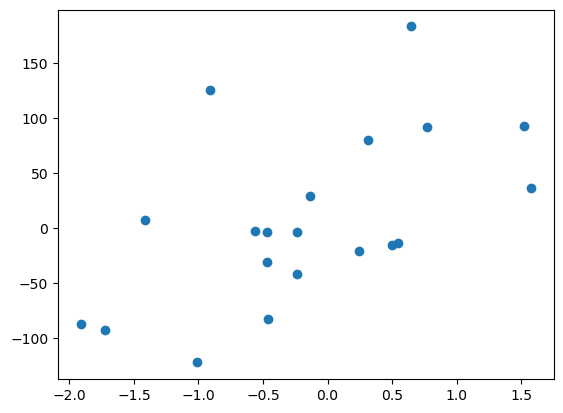

In [17]:
plt.scatter(X,y)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train , X_test , y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [22]:
y_pred

array([ 32.01374571,   1.97308212, -65.87151893,  26.24320773])

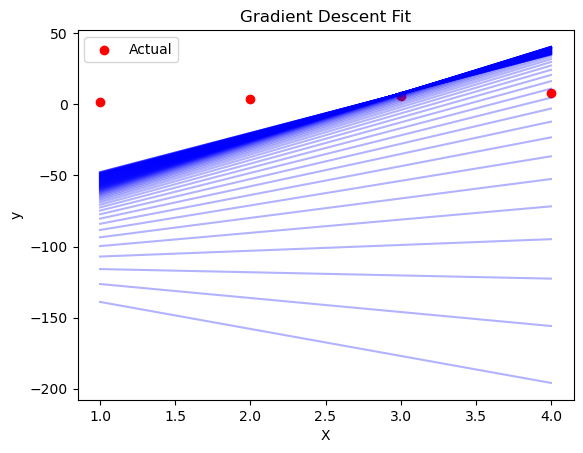

Final parameters: m = 27.49, b = -74.95


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (1 feature)
X = np.array([1,2,3,4], dtype=float)
y = np.array([2,4,6,8], dtype=float)

# Initialize parameters
m = -19
b = -120
epochs = 100
lr = 0.01
n = len(X)

plt.scatter(X, y, color='red', label='Actual')

for i in range(epochs):
    y_pred = m*X + b
    
    # Gradients
    grad_m = (2/n) * np.sum((y_pred - y) * X)
    grad_b = (2/n) * np.sum(y_pred - y)
    
    # Update parameters
    m = m - lr * grad_m
    b = b - lr * grad_b
    
    # Plot prediction line
    plt.plot(X, y_pred, color='blue', alpha=0.3)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Gradient Descent Fit")
plt.legend()
plt.show()

print(f"Final parameters: m = {m:.2f}, b = {b:.2f}")

In [ ]:
import numpy as np

class MiniBatchGradientDescent:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        # Initialize weights and bias
        self.weights = np.zeros(n)
        self.bias = 0
        
        for epoch in range(self.epochs):
            # 1. SHUFFLE DATA (Crucial to prevent order memorization)
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            # 2. Iterate through the data in batches
            for i in range(0, m, self.batch_size):
                # Slice out the current batch
                X_batch = X_shuffled[i : i + self.batch_size]
                y_batch = y_shuffled[i : i + self.batch_size]
                
                b = len(X_batch) # Actual size of the current batch
                
                # 3. Forward Pass (Predictions for the batch)
                y_pred = np.dot(X_batch, self.weights) + self.bias
                
                # 4. Calculate Error
                error = y_pred - y_batch
                
                # 5. Compute Gradients for the batch
                dw = (1 / b) * np.dot(X_batch.T, error)
                db = (1 / b) * np.sum(error)
                
                # 6. Update Weights IMMEDIATELY
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
                
                # Record the cost for plotting later
                cost = (1 / (2 * b)) * np.sum(error ** 2)
                self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Usage:
# model = MiniBatchGradientDescent(learning_rate=0.1, epochs=50, batch_size=32)
# model.fit(X_train, y_train)

In [2]:
import numpy as np

class MiniBatchGD:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.w = None
        self.b = None

    def fit(self, X, y):
        self.w = np.random.randn(X.shape[1])
        self.b = 0
        n_samples = X.shape[0]

        for epoch in range(self.epochs):
            # 1. Shuffle data (Zaroori hai har epoch mein)
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # 2. Batches mein divide karein
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                y_batch = y_shuffled[i : i + self.batch_size]

                # 3. Math: Gradient Calculation
                y_pred = np.dot(X_batch, self.w) + self.b
                error = y_batch - y_pred
                
                # Derivates (Dhalan)
                w_grad = -(2 / len(X_batch)) * np.dot(X_batch.T, error)
                b_grad = -(2 / len(X_batch)) * np.sum(error)

                # 4. Update Weights
                self.w -= self.lr * w_grad
                self.b -= self.lr * b_grad

        return self.w, self.b

I0000 00:00:1775365096.291044    6161 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775365096.853048    6161 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775365099.355539    6161 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/majid-hussain/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775365100.943532    6161 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Fa

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


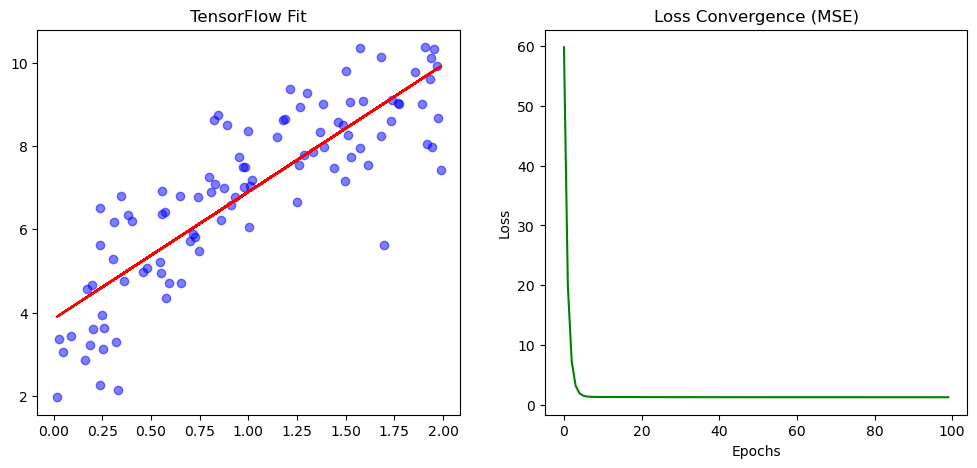

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Generation
X = 2 * np.random.rand(100, 1).astype(np.float32)
y = 4 + 3 * X + np.random.randn(100, 1).astype(np.float32)

# 2. Build Model (Simple Linear Layer)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])

# 3. Compile Model (Batch Gradient Descent setup)
# Optimizer: SGD (Stochastic Gradient Descent)
# Loss: Mean Squared Error (MSE)
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1), loss='mse')

# 4. Training (Batch size = total samples means 'Batch' GD)
# Epochs = Iterations
history = model.fit(X, y, epochs=100, batch_size=len(X), verbose=0)

# 5. Result Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Regression Line
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', alpha=0.5)
plt.plot(X, model.predict(X), color='red', label='TF Prediction')
plt.title("TensorFlow Fit")

# Plot 2: Loss Curve (Cost History)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='green')
plt.title("Loss Convergence (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

In [1]:
import datetime
today = datetime.date.today()
print("Todays' date :", today)

Todays' date : 2026-04-05
